# Segmentation errors Evaluation

- Dice score
- Jacquard index (IoU)
- Yasnoff
- Hausdorff : check https://github.com/jeromerony/distorch
- precision and recall, f1 score

In [3]:
!ls imgs

STD_AOST_PreStent.tif  patient1_seg.tif  patient3.tif
patient1_no_seg.bmp    patient2.tif


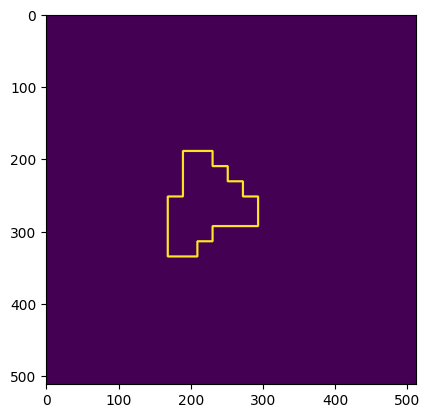

In [2]:
import matplotlib.pyplot as plt
img_seg = plt.imread("imgs/patient1_seg.tif")

img = plt.imread("test_seg.bmp")
plt.imshow(img)

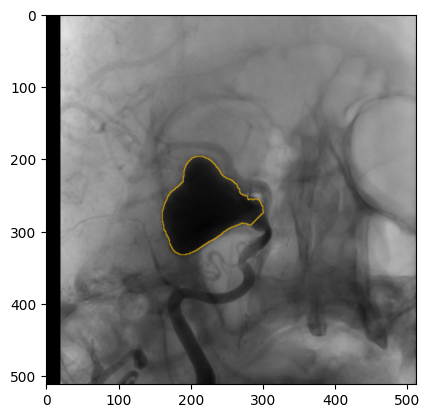

In [3]:
plt.imshow(img_seg)

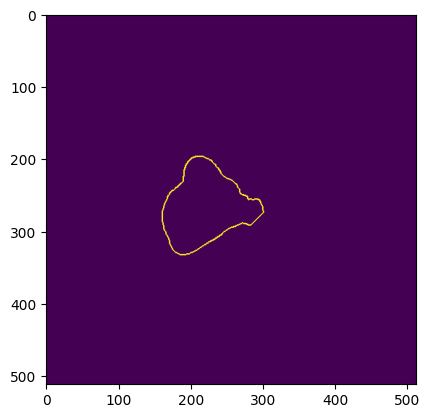

In [4]:
seg_ref = (img_seg[:, :, 0] > 100) & (img_seg[:, :, 1] > 100) & (img_seg[:, :, 2] < 100)
plt.imshow(seg_ref)

In [5]:
import numpy as np
import scipy as sp
import scipy.ndimage

def flood_fill(test_array,h_max=255):
    input_array = np.copy(test_array) 
    el = sp.ndimage.generate_binary_structure(2,2).astype(np.int32)
    inside_mask = sp.ndimage.binary_erosion(~np.isnan(input_array), structure=el)
    output_array = np.copy(input_array)
    output_array[inside_mask]=h_max
    output_old_array = np.copy(input_array)
    output_old_array.fill(0)   
    el = sp.ndimage.generate_binary_structure(2,1).astype(np.int32)
    while not np.array_equal(output_old_array, output_array):
        output_old_array = np.copy(output_array)
        output_array = np.maximum(input_array,sp.ndimage.grey_erosion(output_array, size=(3,3), footprint=el))
    return output_array

In [6]:
area_seg_ref = flood_fill(seg_ref)
area_test_seg = flood_fill(img[:,:,0]>200)

/tmp/ipykernel_1790/1348976280.py:16: UserWarning: ignoring size because footprint is set
  output_array = np.maximum(input_array,sp.ndimage.grey_erosion(output_array, size=(3,3), footprint=el))


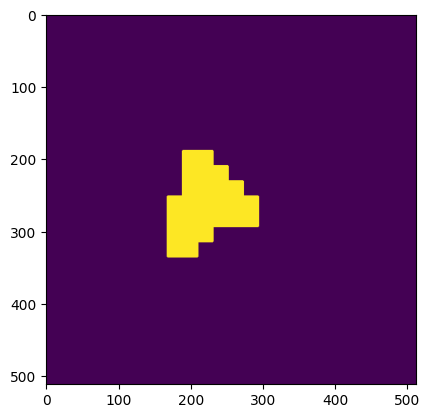

In [6]:
plt.imshow(area_test_seg)


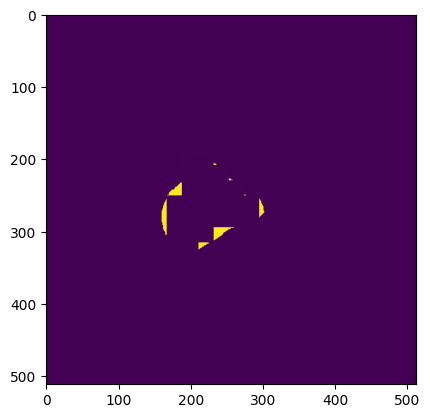

In [7]:
plt.imshow(-area_seg_ref.astype("uint8") +area_test_seg.astype("uint8"))

In [8]:
np.sum(area_seg_ref.astype("uint8") -area_test_seg.astype("uint8")!=0)

np.int64(2392)

In [11]:
np.sum(area_seg_ref.astype("uint8") + area_test_seg.astype("uint8")>1)

np.int64(10514)

## 1.Instersection over Union (aka Jacquard index)

In [7]:
def IoU2D(binary_seg, binary_ref):
    _inters = np.sum((binary_seg.astype("uint8") +binary_ref.astype("uint8"))==1)
    _union = np.sum((binary_seg.astype("uint8") + binary_ref.astype("uint8"))>1)

    return _inters/float(_union)

In [8]:
IoU2D(area_test_seg, area_test_seg)

np.float64(0.0)

## 2. Dice score

In [9]:
def dice_score2D(binary_seg, binary_ref):
    # 2 XoverY/(|x|+|Y|)
    _inters = np.sum((binary_seg.astype("uint8") +binary_ref.astype("uint8"))==1)
    _sum = np.sum(binary_seg.astype("uint8")==1) + np.sum(binary_ref.astype("uint8")==1)

    return 2 *_inters/float(_sum)

In [10]:
dice_score2D(area_test_seg, area_test_seg)

np.float64(0.0)

## 3. Yasnoff & Hausdorff distance

In [23]:
def yasnoff2D(test, ref):
    """Cr.Yasnoff=100×√(∑_i^(card(I))▒〖d²(i)〗)/N_tot 
    here we compute a symetric version of the distance
    """
    test = (test == 1)
    ref = (ref == 1)

    stored1 = _yasnoff2D(test, ref)
    stored2 = _yasnoff2D(ref, test)

    return np.sqrt(np.sum(stored1) + np.sum(stored2)) / 200
    
def _yasnoff2D(area1, area2):
    test_pts = np.argwhere(area1 == 1)
    ref_pts = np.argwhere(area2 == 1)
    
    stored = []
    
    for p in test_pts:
        d = np.linalg.norm(ref_pts - p, axis=1)
        stored.append(d.min()**2)
    return stored

def _hausdorff2D(area1, area2):
    test_pts = np.argwhere(area1 == 1)
    ref_pts = np.argwhere(area2 == 1)
    
    stored, pts = [], []
    
    for p in test_pts:
        d = np.linalg.norm(ref_pts - p, axis=1)
        stored.append(d.max())
        pts.append(test_pts[d.argmax()])
    return stored, pts

def hausdorff2D(area1, area2):
    """computes hausdorff distance 
    h(A,B)=a∈Amax​b∈Bmin​d(a,b)
    """
    area1 = (area1==1)
    area2 = area2==1

    stored1 = _hausdorff2D(area1, area2)
    stored2 = _hausdorff2D(area2, area1)
    hd = np.max((stored1 + stored2))
    return hd

In [24]:
hausdorff2D(area_test_seg, area_seg_ref)






np.float64(151.82226450688975)

## 4. Precsion, Recall and F1-score

In [66]:

# recall TP/(TP+FN)

def precision_seg2D(seg, ref):
    # precision TP/(TP+FP)
    seg = (seg == 1)
    ref = ref ==1
    true_pos = np.sum( (seg.astype("uint8")+ref.astype("uint8")) ==2)
    false_pos = np.sum((seg.astype("uint8") - ref.astype("uint8"))>1)
    print(false_pos)
    return float(true_pos)/ float(true_pos + false_pos)


def recall_seg2D(seg, ref):
    # recall TP/(TP+FN)
    seg = (seg == 1)
    ref = ref ==1
    true_pos = np.sum( (seg.astype("uint8")+ref.astype("uint8")) ==2)
    false_neg = np.sum(( ref.astype("uint8") - seg.astype("uint8") )>1)
    print(false_neg)
    return float(true_pos) / float(true_pos + false_neg)
    

def F1_score(seg, ref):
    # 2*precsion * recall / (precision + recall)
    precision = precision_seg2D(seg, ref)
    recall = recall_seg2D(seg, ref)

    return 2 * precision * recall / (precsion + recall)


print(precision_seg2D(area_test_seg, area_seg_ref))
recall_seg2D(area_test_seg, area_seg_ref)

900
0.9211494655686
1492


0.8757288022655338

In [51]:
np.sum(( -area_test_seg.astype("uint8") + area_seg_ref.astype("uint8") )>0)

np.int64(2392)

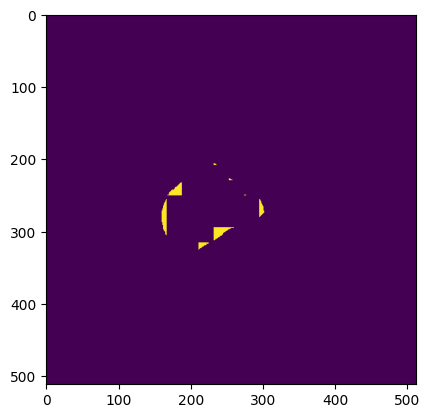

In [65]:
plt.imshow(+area_test_seg.astype("uint8") - area_seg_ref.astype("uint8") >1)

In [36]:
area_test_seg.astype("uint8") - area_test_seg.astype("uint8")

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(512, 512), dtype=uint8)

In [10]:
np.sum(stored) / len(stored)

np.float64(0.5573445630462062)

In [37]:
stored = []
for y in range(len((area_test_seg==1).astype("uint8"))):
    for x in range(len((area_test_seg==1).astype("uint8")[y])):
        dist = []
        for y_ref in range(len((area_seg_ref==1).astype("uint8"))):
            for x_ref in range(len((area_seg_ref==1).astype("uint8")[y])):
                dist.append(np.linalg.norm(np.array([x_ref, y_ref]) - np.array([x,y])))
        stored.append(min(dist))
        

KeyboardInterrupt: 

In [67]:
def makeTable(headerRow,columnizedData,columnSpacing=2):
    """Creates a technical paper style, left justified table

    Author: Christopher Collett
    Date: 6/1/2019
    ex:
    header = ['Name','Age']
    names = ['George','Alberta','Frank']
    ages = [8,9,11]
    makeTable(header,[names,ages])
    
    """
    from numpy import array,max,vectorize

    cols = array(columnizedData,dtype=str)
    colSizes = [max(vectorize(len)(col)) for col in cols]

    header = ''
    rows = ['' for i in cols[0]]

    for i in range(0,len(headerRow)):
        if len(headerRow[i]) > colSizes[i]: colSizes[i]=len(headerRow[i])
        headerRow[i]+=' '*(colSizes[i]-len(headerRow[i]))
        header+=headerRow[i]
        if not i == len(headerRow)-1: header+=' '*columnSpacing

        for j in range(0,len(cols[i])):
            if len(cols[i][j]) < colSizes[i]:
                cols[i][j]+=' '*(colSizes[i]-len(cols[i][j])+columnSpacing)
            rows[j]+=cols[i][j]
            if not i == len(headerRow)-1: rows[j]+=' '*columnSpacing

    line = '-'*len(header)
    print(line)
    print(header)
    print(line)
    for row in rows: print(row)
    print(line)

------------
Name     Age
------------
George   8    
Alberta  9    
Frank    11   
------------
